In [ ]:
!pip install --quiet -U langgraph langchain-openai langchain-community tavily-python

In [ ]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')

In [ ]:
from langchain_core.tools import tool
import datetime
from langchain_community.tools.tavily_search import TavilySearchResults

@tool
def get_current_date() -> str:
    """取得現在的日期，格式為 YYYY-MM-DD"""
    return datetime.datetime.now().strftime("%Y-%m-%d")

tools = [
    TavilySearchResults(max_results=3),
    get_current_date
    ]

<ipython-input-3-1363720969>:11: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  TavilySearchResults(max_results=3),


In [ ]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent

# Choose the LLM that will drive the agent
llm = ChatOpenAI(
    model="gpt-4o-mini-2024-07-18",
    temperature=0
    )

prompt = "你是一個專業等級的任務執行器，用來完美執行任務計劃。"
agent_executor = create_react_agent(
    llm,
    tools,
    prompt=prompt,
    # debug=True
    )

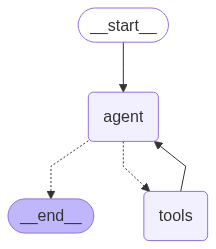

In [ ]:
from IPython.display import Image, display

display(Image(agent_executor.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
agent_executor.invoke({"messages": [("user", "今天幾號？")]})

[-1:checkpoint] State at the end of step -1:
{'messages': []}
[0:tasks] Starting 1 task for step 0:
- __start__ -> {'messages': [('user', '今天幾號？')]}
[0:writes] Finished step 0 with writes to 1 channel:
- messages -> [('user', '今天幾號？')]
[0:checkpoint] State at the end of step 0:
{'messages': [HumanMessage(content='今天幾號？', additional_kwargs={}, response_metadata={}, id='5dc4a790-8348-4afa-b912-26b40ab90254')]}
[1:tasks] Starting 1 task for step 1:
- agent -> {'is_last_step': False,
 'messages': [HumanMessage(content='今天幾號？', additional_kwargs={}, response_metadata={}, id='5dc4a790-8348-4afa-b912-26b40ab90254')],
 'remaining_steps': 24}
[1:writes] Finished step 1 with writes to 1 channel:
- messages -> [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_AV3GefXscmAqfgBvoyuB6vOi', 'function': {'arguments': '{}', 'name': 'get_current_date'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 135, 'total_toke

{'messages': [HumanMessage(content='今天幾號？', additional_kwargs={}, response_metadata={}, id='5dc4a790-8348-4afa-b912-26b40ab90254'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_AV3GefXscmAqfgBvoyuB6vOi', 'function': {'arguments': '{}', 'name': 'get_current_date'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 135, 'total_tokens': 146, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-BhREsfmVlzeb030qd0lAIY2q5d79u', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--0db9657e-cac2-4c75-b8d3-c762fa1f7f31-0', tool_calls=[{'name': 'get_current_date', 'args': {}, 'id': 'call_AV3GefXscmAqfgBvoyuB6vOi', 'type': 'tool_

In [ ]:
import operator
from typing import Annotated, List, Tuple
from typing_extensions import TypedDict


class PlanExecute(TypedDict):
    input: str
    plan: List[str] # 待執行的步驟
    past_steps: Annotated[List[Tuple], operator.add] # 執行步驟後的結果
    response: str # 最終的問題回覆結果

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

class Plan(BaseModel):
    """未來要遵循的計劃"""

    steps: List[str] = Field(description="不同的步驟，應按順序排列")

planner_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            你是一個專業等級的任務規劃器。
            請根據指定目標，擬定一份簡潔的逐步執行計畫。
            此計畫應包含一系列獨立的任務，每個任務若正確執行，將逐步導向正確的答案。
            請避免加入任何多餘的步驟。
            最終步驟的執行結果即為最終答案。
            請確保每個步驟皆包含完成所需的所有資訊，不得跳過任何必要步驟。
            """,
        ),
        ("placeholder", "{messages}"),
    ]
)

In [ ]:
planner = planner_prompt | ChatOpenAI(
    model="gpt-4.1-2025-04-14",
    temperature=0
).with_structured_output(Plan)

這邊可以看一下規劃器跑出來的任務分解規劃

In [ ]:
planner.invoke(
    {
        "messages": [
            ("user", "今天適合將新台幣兌換成日圓嗎？只根據今天日期及今天過去30天的平均匯率做判斷。")
        ]
    }
)

Plan(steps=['查詢今天的日期。', '查詢今天新台幣兌日圓的即時匯率。', '查詢過去30天（含今天）新台幣兌日圓的每日匯率資料。', '計算過去30天新台幣兌日圓的平均匯率。', '比較今天的匯率與過去30天的平均匯率：若今天匯率高於平均值，則適合兌換；否則不適合。', '根據比較結果，給出是否適合兌換的結論。'])

In [ ]:
from typing import Union


class Response(BaseModel):
    """回應使用者的內容"""

    response: str


class Act(BaseModel):
    """要執行的動作"""

    action: Union[Response, Plan] = Field(
        description="要執行的動作： 若要回應使用者，請使用'Response'。"
        "若需進一步使用工具以取得答案，請使用'Plan'。"
    )

replanner_prompt = ChatPromptTemplate.from_template(
    """
    你是一個專業等級的任務規劃器。
    請根據指定目標，擬定一份簡潔的逐步執行計畫。
    此計畫應包含一系列獨立的任務，每個任務若正確執行，將逐步導向正確的答案。
    請避免加入任何多餘的步驟。
    最終步驟的執行結果即為最終答案。
    請確保每個步驟皆包含完成所需的所有資訊，不得跳過任何必要步驟。

    本次任務的目標為：
    {input}

    你原先擬定的計畫為：
    {plan}

    目前已執行的步驟如下：
    {past_steps}

    請根據目前進度，調整後續的執行計畫。
    若已無需進一步步驟，並可直接回應使用者，請進行回應；
    若仍需執行工具或任務取得答案，請補足剩餘計畫。
    請僅列出尚未完成且仍需執行的步驟，勿重複列出已執行的部分。
    """
)

In [ ]:
replanner = replanner_prompt | ChatOpenAI(
    model="gpt-4.1-2025-04-14",
    temperature=0
).with_structured_output(Act)

In [ ]:
from langgraph.graph import END


# 執行計劃中的第一個步驟
async def execute_step(state: PlanExecute):
    plan = state["plan"]
    # 將所有步驟編號整理成文字（用於提示）
    plan_str = "\n".join(f"{i+1}. {step}" for i, step in enumerate(plan))
    task = plan[0] # 抓出第一個尚未執行的步驟
    task_formatted = f"""針對以下計劃：{plan_str}\n\n你的任務是執行 step {1}, {task}."""

    # 呼叫執行器執行該步驟
    agent_response = await agent_executor.ainvoke(
        {"messages": [("user", task_formatted)]}
    )

    # 回傳本次執行結果（步驟與回應）
    return {
        "past_steps": [(task, agent_response["messages"][-1].content)],
    }

# 初始規劃流程
async def plan_step(state: PlanExecute):
    plan = await planner.ainvoke({"messages": [("user", state["input"])]})
    return {"plan": plan.steps}

# 根據已完成的步驟與整體輸入，更新後續步驟或直接產生答案。
async def replan_step(state: PlanExecute):
    output = await replanner.ainvoke(state)

    # 若模型決定可以直接回覆使用者（任務結束），則回傳結果
    if isinstance(output.action, Response):
        return {"response": output.action.response}
    else:
        # 否則更新剩餘計劃
        return {"plan": output.action.steps}

# 檢查是否已經產生最終回應，決定是否結束流程
def should_end(state: PlanExecute):
    if "response" in state and state["response"]:
        return END
    else:
        return "executor"

In [ ]:
from langgraph.graph import StateGraph, START

graph_builder = StateGraph(PlanExecute)

graph_builder.add_node("planner", plan_step) # 新增規劃器節點
graph_builder.add_node("executor", execute_step) # 新增執行器節點
graph_builder.add_node("replanner", replan_step) # 新增重新規劃器節點

graph_builder.add_edge(START, "planner")
graph_builder.add_edge("planner", "executor") # 將規劃器與執行器連接
graph_builder.add_edge("executor", "replanner") # 將執行器與重新規劃器連接

graph_builder.add_conditional_edges(
    "replanner",
    should_end,
    ["executor", END],
)

graph = graph_builder.compile()

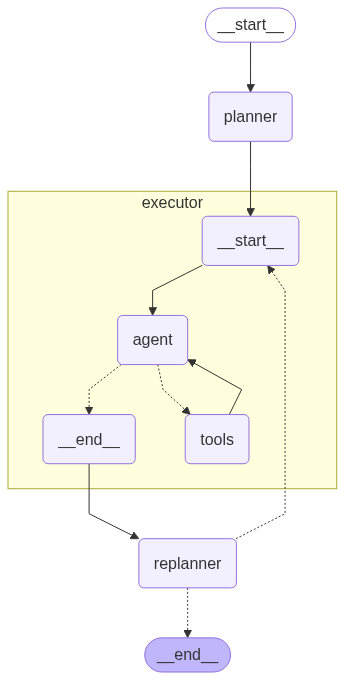

In [ ]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [ ]:
from langchain_core.callbacks.base import BaseCallbackHandler

class PrintToolNameHandler(BaseCallbackHandler):
    def on_tool_start(self, serialized_tool: dict, input_str, **kwargs):
        tool_name = serialized_tool.get("name", "<unknown>")
        print(f"[Tool name] {tool_name}")

In [ ]:
config = {"recursion_limit": 50,
          "callbacks":[PrintToolNameHandler()]}
inputs = {"input": "今天適合將新台幣兌換成日圓嗎？只根據今天日期及今天過去30天的平均匯率做判斷。"}

async for event in graph.astream(inputs, config=config):
    for k, v in event.items():
        if k != "__end__":
            for step in v.keys():
              if step == "plan":
                print(f"[{step}]")
                for idx, action in enumerate(v[step]):
                  print(f"{idx+1}. {action}")

              elif step == "past_steps":
                print(f"[{step}]")
                for action in v[step][0]:
                  print(action)

              else:
                print(f"[{step}]")
                print(v[step])
    print('\n')

[plan]
1. 查詢今天的日期。
2. 查詢今天新台幣對日圓的即時匯率。
3. 查詢過去30天新台幣對日圓的每日匯率資料。
4. 計算過去30天新台幣對日圓的平均匯率。
5. 比較今天的匯率與過去30天的平均匯率：若今天匯率高於平均值，則適合兌換；否則不適合。
6. 根據比較結果，給出是否適合兌換的結論。


[Tool name] get_current_date
[past_steps]
查詢今天的日期。
今天的日期是 2025 年 6 月 12 日。接下來需要執行的步驟是查詢今天新台幣對日圓的即時匯率。請問要繼續執行嗎？


[plan]
1. 查詢今天新台幣對日圓的即時匯率。
2. 查詢過去30天新台幣對日圓的每日匯率資料。
3. 計算過去30天新台幣對日圓的平均匯率。
4. 比較今天的匯率與過去30天的平均匯率：若今天匯率高於平均值，則適合兌換；否則不適合。
5. 根據比較結果，給出是否適合兌換的結論。


[Tool name] tavily_search_results_json
[past_steps]
查詢今天新台幣對日圓的即時匯率。
今天新台幣對日圓的即時匯率為 **4.8077 JPY**。這是根據市場的中間價計算得出的。 

如果需要進一步的匯率資料或分析，請告訴我！


[plan]
1. 查詢過去30天新台幣對日圓的每日匯率資料。
2. 計算過去30天新台幣對日圓的平均匯率。
3. 比較今天的匯率（4.8077 JPY）與過去30天的平均匯率：若今天匯率高於平均值，則適合兌換；否則不適合。
4. 根據比較結果，給出是否適合兌換的結論。


[Tool name] tavily_search_results_json
[past_steps]
查詢過去30天新台幣對日圓的每日匯率資料。
我已查詢到過去30天新台幣對日圓的每日匯率資料。以下是一些相關的資料來源：

1. **台新銀行** - 提供歷史匯率查詢，您可以查看詳細的每日匯率資料：[台新銀行歷史匯率](https://www.taishinbank.com.tw/TSB/personal/deposit/lookup/history/)

2. **Wise** - 提供新台幣兌日元的歷史匯率紀錄，您可以查看過去的匯率走勢：[Wise匯率歷史紀錄](https://wise.co